# 2. Feature Extraction & ML Classification

This notebook covers Phase 2–3 of the lung sound classification project:
- Patient-aware data splitting (no leakage between train/val/test)
- Handcrafted audio feature extraction (MFCCs, spectral features, chroma, ZCR)
- Mel spectrogram extraction for CNN/CRNN input
- Traditional ML baselines: SVM, Random Forest, XGBoost, Gradient Boosting
- SMOTE oversampling to address class imbalance (Normal: 52.8% vs Both: 7.3%)

**Dataset**: 6,898 respiratory cycles from 126 patients across 920 recordings.

In [1]:
import sys
sys.path.append(r"E:\GitHub\lung-sound-classification")

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import joblib

from src.config import *
from src.data_loader import load_cycle_audio, patient_split, load_diagnosis
from src.feature_extraction import extract_handcrafted_features, extract_mel_spectrogram

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete.")

Setup complete.


## 2.1 Load Processed Data
Loading the cycle-level dataset generated during EDA. Each row represents one respiratory cycle with its annotation (Normal/Crackle/Wheeze/Both) and patient metadata.

In [2]:
# Load the cycle dataset from EDA
cycle_df = pd.read_csv(DATA_DIR / 'cycle_dataset.csv')
cycle_df['label'] = cycle_df['label'].astype(int)
cycle_df['crackle'] = cycle_df['crackle'].astype(int)
cycle_df['wheeze'] = cycle_df['wheeze'].astype(int)

print(f"Total cycles: {len(cycle_df)}")
print(f"Class distribution:\n{cycle_df['label'].value_counts().sort_index()}")

Total cycles: 6898
Class distribution:
label
0    3642
1    1864
2     886
3     506
Name: count, dtype: int64


## 2.2 Patient-Aware Train/Val/Test Split
Critical design choice: we split by **patient**, not by cycle. A single patient can contribute dozens of cycles, and if their cycles appear in both train and test sets, the model learns patient-specific acoustic features rather than generalisable respiratory patterns. This is a common source of inflated accuracy in medical ML that we deliberately avoid.

- **Train**: ~65% of patients
- **Validation**: ~15% of patients
- **Test**: ~20% of patients

In [3]:
# Patient-aware train/val/test split
train_df, val_df, test_df = patient_split(cycle_df)

# Verify no patient leakage
train_patients = set(train_df['patient_id'])
val_patients = set(val_df['patient_id'])
test_patients = set(test_df['patient_id'])

assert train_patients.isdisjoint(val_patients), "LEAK: train/val overlap!"
assert train_patients.isdisjoint(test_patients), "LEAK: train/test overlap!"
assert val_patients.isdisjoint(test_patients), "LEAK: val/test overlap!"
print("No patient leakage confirmed.")

# Class distribution per split
for name, df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    counts = df['label'].value_counts().sort_index()
    print(f"\n{name} class distribution:")
    for i, c in enumerate(CYCLE_CLASS_NAMES):
        print(f"  {c}: {counts.get(i, 0)}")

Split sizes — Train: 3809, Val: 1386, Test: 1703
Unique patients — Train: 81, Val: 19, Test: 26
No patient leakage confirmed.

Train class distribution:
  Normal: 2257
  Crackle: 841
  Wheeze: 491
  Both: 220

Val class distribution:
  Normal: 585
  Crackle: 506
  Wheeze: 171
  Both: 124

Test class distribution:
  Normal: 800
  Crackle: 517
  Wheeze: 224
  Both: 162


## 2.3 Audio Segment Extraction
Load raw audio waveforms for each respiratory cycle. Each segment is:
- Extracted from the full recording using annotation start/end times
- Resampled to 22,050 Hz
- Padded with silence or truncated to a fixed 5-second duration

This standardisation ensures uniform input dimensions for all downstream models.

In [4]:
#  Extract audio segments 
def extract_audio_segments(df, desc="Extracting"):
    """Load and pad/truncate all audio segments from a DataFrame."""
    segments = []
    failed = 0
    for idx, row in tqdm(df.iterrows(), total=len(df), desc=desc):
        try:
            y = load_cycle_audio(row['audio_path'], row['start'], row['end'])
            segments.append(y)
        except Exception as e:
            # Fallback: silence
            segments.append(np.zeros(int(CYCLE_DURATION * SAMPLE_RATE)))
            failed += 1
    if failed > 0:
        print(f"  Warning: {failed} segments failed to load.")
    return segments

print("Extracting train audio...")
train_audio = extract_audio_segments(train_df, "Train")
print("Extracting val audio...")
val_audio = extract_audio_segments(val_df, "Val")
print("Extracting test audio...")
test_audio = extract_audio_segments(test_df, "Test")

print(f"\nTrain: {len(train_audio)}, Val: {len(val_audio)}, Test: {len(test_audio)}")

Extracting train audio...


Train: 100%|██████████| 3809/3809 [00:04<00:00, 768.33it/s] 


Extracting val audio...


Val: 100%|██████████| 1386/1386 [00:01<00:00, 1032.97it/s]


Extracting test audio...


Test: 100%|██████████| 1703/1703 [00:01<00:00, 1007.96it/s]


Train: 3809, Val: 1386, Test: 1703


## 2.4 Handcrafted Feature Extraction (for ML Models)
For each 5-second audio segment, we extract a comprehensive feature vector comprising:

| Feature Group | Components | Dimensions |
|---|---|---|
| MFCCs | 40 coefficients × (mean + std) | 80 |
| MFCC Deltas | 40 × (mean + std) | 80 |
| MFCC Delta-Deltas | 40 × (mean + std) | 80 |
| Chroma | 12 × (mean + std) | 24 |
| Spectral Centroid | mean + std | 2 |
| Spectral Bandwidth | mean + std | 2 |
| Spectral Contrast | 7 bands × (mean + std) | 14 |
| Spectral Rolloff | mean + std | 2 |
| Zero-Crossing Rate | mean + std | 2 |
| RMS Energy | mean + std | 2 |

These features capture both timbral (MFCCs) and spectral properties that distinguish crackles (broadband, transient) from wheezes (narrowband, sustained).

In [6]:
# Extract handcrafted features for ML models
def extract_features_from_segments(segments, desc="Features"):
    """Extract handcrafted audio features from a list of segments."""
    features = []
    for i, y in enumerate(tqdm(segments, desc=desc)):
        try:
            feat = extract_handcrafted_features(y, sr=SAMPLE_RATE)
            features.append(feat)
        except Exception as e:
            # Use zeros if extraction fails
            if features:
                features.append(np.zeros_like(features[-1]))
            else:
                features.append(np.zeros(264))
    return np.array(features)

print("Extracting handcrafted features")


X_train_hc = extract_features_from_segments(train_audio, "Train features")
X_val_hc = extract_features_from_segments(val_audio, "Val features")
X_test_hc = extract_features_from_segments(test_audio, "Test features")

y_train = train_df['label'].values
y_val = val_df['label'].values
y_test = test_df['label'].values

print(f"\nFeature shapes:")
print(f"  Train: {X_train_hc.shape}")
print(f"  Val:   {X_val_hc.shape}")
print(f"  Test:  {X_test_hc.shape}")

# Save features so we don't have to re-extract
np.savez(
    DATA_DIR / 'handcrafted_features.npz',
    X_train=X_train_hc, X_val=X_val_hc, X_test=X_test_hc,
    y_train=y_train, y_val=y_val, y_test=y_test
)
print("Saved handcrafted features to disk.")

Extracting handcrafted features


Test features: 100%|██████████| 1703/1703 [00:43<00:00, 39.04it/s]


Feature shapes:
  Train: (3809, 288)
  Val:   (1386, 288)
  Test:  (1703, 288)
Saved handcrafted features to disk.


## 2.5 Mel Spectrogram Extraction (for CNN/CRNN Models)
Mel spectrograms convert raw audio into 2D time-frequency representations:
- **128 mel-frequency bins** (y-axis) — perceptually spaced frequency bands
- **Time frames** (x-axis) — computed with 512-sample hop length
- **Log-scaled power** (dB) — matches human loudness perception

These spectrograms serve as "images" that CNN and CRNN models can learn from, capturing both the frequency content and temporal evolution of respiratory sounds.

In [7]:
# Extract mel spectrograms for CNN/CRNN
print("Extracting mel spectrograms")

def extract_spectrograms(segments, desc="Spectrograms"):
    specs = []
    for y in tqdm(segments, desc=desc):
        try:
            spec = extract_mel_spectrogram(y, sr=SAMPLE_RATE)
            specs.append(spec)
        except:
            specs.append(np.zeros((N_MELS, int(CYCLE_DURATION * SAMPLE_RATE / HOP_LENGTH) + 1)))
    return np.array(specs)

X_train_spec = extract_spectrograms(train_audio, "Train spectrograms")
X_val_spec = extract_spectrograms(val_audio, "Val spectrograms")
X_test_spec = extract_spectrograms(test_audio, "Test spectrograms")

print(f"\nSpectrogram shapes:")
print(f"  Train: {X_train_spec.shape}")
print(f"  Val:   {X_val_spec.shape}")
print(f"  Test:  {X_test_spec.shape}")

# Save spectrograms
np.savez(
    DATA_DIR / 'mel_spectrograms.npz',
    X_train=X_train_spec, X_val=X_val_spec, X_test=X_test_spec,
    y_train=y_train, y_val=y_val, y_test=y_test
)
print("Saved mel spectrograms to disk.")

Extracting mel spectrograms


Test spectrograms: 100%|██████████| 1703/1703 [00:07<00:00, 225.28it/s]



Spectrogram shapes:
  Train: (3809, 128, 216)
  Val:   (1386, 128, 216)
  Test:  (1703, 128, 216)
Saved mel spectrograms to disk.


## 2.6 ML Model Training & Evaluation
We train four traditional ML classifiers on the handcrafted features:

1. **SVM (RBF kernel)** — strong with high-dimensional features, effective decision boundaries
2. **Random Forest** — ensemble of decision trees, robust to overfitting
3. **XGBoost** — gradient-boosted trees, often state-of-the-art for tabular data
4. **Gradient Boosting** — scikit-learn's implementation for comparison

**Handling class imbalance**: SMOTE (Synthetic Minority Oversampling Technique) generates synthetic samples for minority classes (Wheeze, Both) in the training set only, ensuring the test set reflects real-world distribution.

After SMOTE: 9028 samples
Class distribution: [2257 2257 2257 2257]

Training SVM (RBF)...

  SVM (RBF)
  Accuracy:          0.4991
  F1 (macro):        0.3164
  F1 (weighted):     0.4532

              precision    recall  f1-score   support

      Normal       0.52      0.77      0.62       800
     Crackle       0.51      0.40      0.45       517
      Wheeze       0.28      0.14      0.19       224
        Both       0.05      0.01      0.01       162

    accuracy                           0.50      1703
   macro avg       0.34      0.33      0.32      1703
weighted avg       0.44      0.50      0.45      1703

  Saved: E:\GitHub\lung-sound-classification\outputs\figures\cm_svm_rbf.png


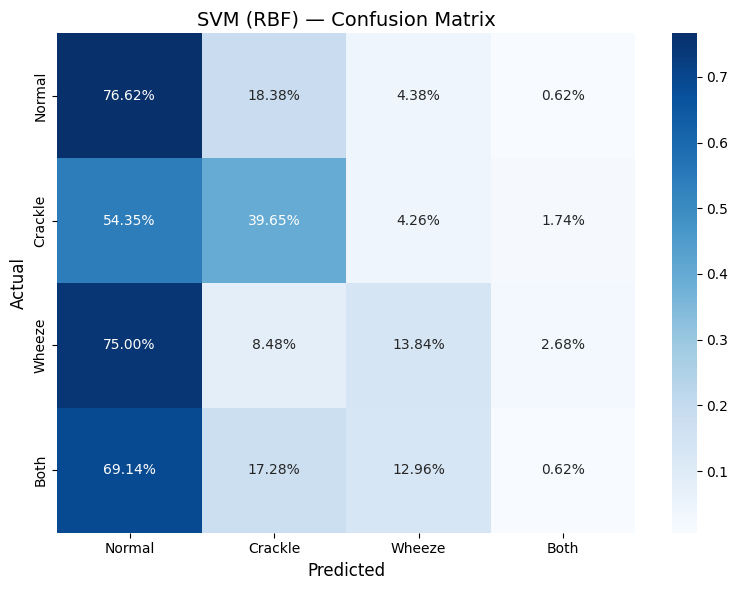


Training Random Forest...

  Random Forest
  Accuracy:          0.4668
  F1 (macro):        0.2679
  F1 (weighted):     0.4100

              precision    recall  f1-score   support

      Normal       0.50      0.77      0.60       800
     Crackle       0.45      0.32      0.38       517
      Wheeze       0.21      0.06      0.09       224
        Both       0.00      0.00      0.00       162

    accuracy                           0.47      1703
   macro avg       0.29      0.29      0.27      1703
weighted avg       0.40      0.47      0.41      1703

  Saved: E:\GitHub\lung-sound-classification\outputs\figures\cm_random_forest.png


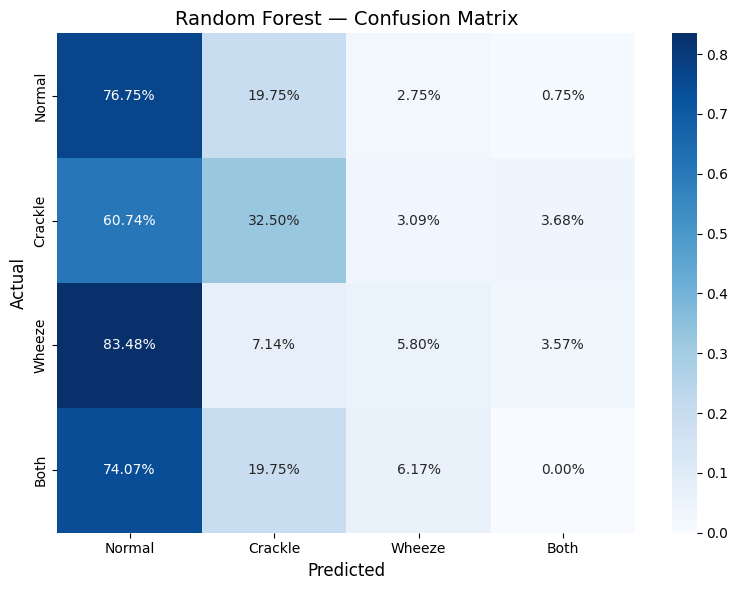


Training XGBoost...

  XGBoost
  Accuracy:          0.4750
  F1 (macro):        0.2896
  F1 (weighted):     0.4269

              precision    recall  f1-score   support

      Normal       0.51      0.76      0.61       800
     Crackle       0.47      0.34      0.39       517
      Wheeze       0.27      0.11      0.15       224
        Both       0.00      0.00      0.00       162

    accuracy                           0.48      1703
   macro avg       0.31      0.30      0.29      1703
weighted avg       0.42      0.48      0.43      1703

  Saved: E:\GitHub\lung-sound-classification\outputs\figures\cm_xgboost.png


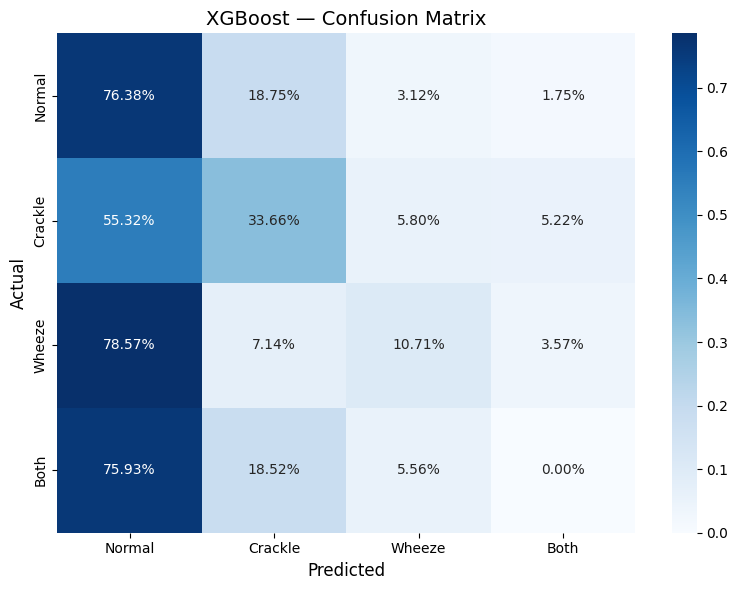


Training Gradient Boosting...

  Gradient Boosting
  Accuracy:          0.4668
  F1 (macro):        0.2957
  F1 (weighted):     0.4255

              precision    recall  f1-score   support

      Normal       0.50      0.73      0.59       800
     Crackle       0.48      0.36      0.41       517
      Wheeze       0.26      0.13      0.17       224
        Both       0.02      0.01      0.01       162

    accuracy                           0.47      1703
   macro avg       0.32      0.30      0.30      1703
weighted avg       0.42      0.47      0.43      1703

  Saved: E:\GitHub\lung-sound-classification\outputs\figures\cm_gradient_boosting.png


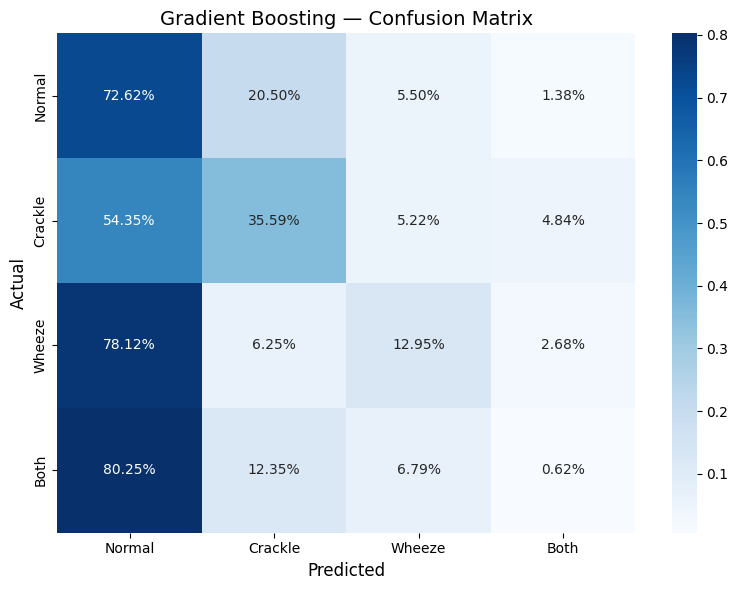


Best ML model: SVM (RBF) (F1 macro: 0.3164)


['E:\\GitHub\\lung-sound-classification\\outputs\\models\\scaler.joblib']

In [8]:
# Train ML models
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from src.evaluate import evaluate_predictions, plot_confusion_matrix, compare_models
from src.models import get_ml_models

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_hc)
X_val_scaled = scaler.transform(X_val_hc)
X_test_scaled = scaler.transform(X_test_hc)

# Handle class imbalance with SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
print(f"After SMOTE: {len(X_train_resampled)} samples")
print(f"Class distribution: {np.bincount(y_train_resampled)}")

# Train all ML models
models = get_ml_models()
ml_results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_test_scaled)
    results = evaluate_predictions(y_test, y_pred, title=name)
    ml_results[name] = results
    
    plot_confusion_matrix(
        y_test, y_pred, title=f"{name} — Confusion Matrix",
        save_path=FIGURES_DIR / f'cm_{name.lower().replace(" ", "_").replace("(", "").replace(")", "")}.png'
    )

# Save best model
best_model_name = max(ml_results, key=lambda k: ml_results[k]['f1_macro'])
print(f"\nBest ML model: {best_model_name} (F1 macro: {ml_results[best_model_name]['f1_macro']:.4f})")
joblib.dump(models[best_model_name], MODELS_DIR / 'best_ml_model.joblib')
joblib.dump(scaler, MODELS_DIR / 'scaler.joblib')

## 2.7 Model Comparison
Side-by-side comparison of accuracy and macro F1-score across all ML models. Macro F1 is the primary metric as it equally weights performance on all four classes, penalising models that only predict the majority class (Normal).

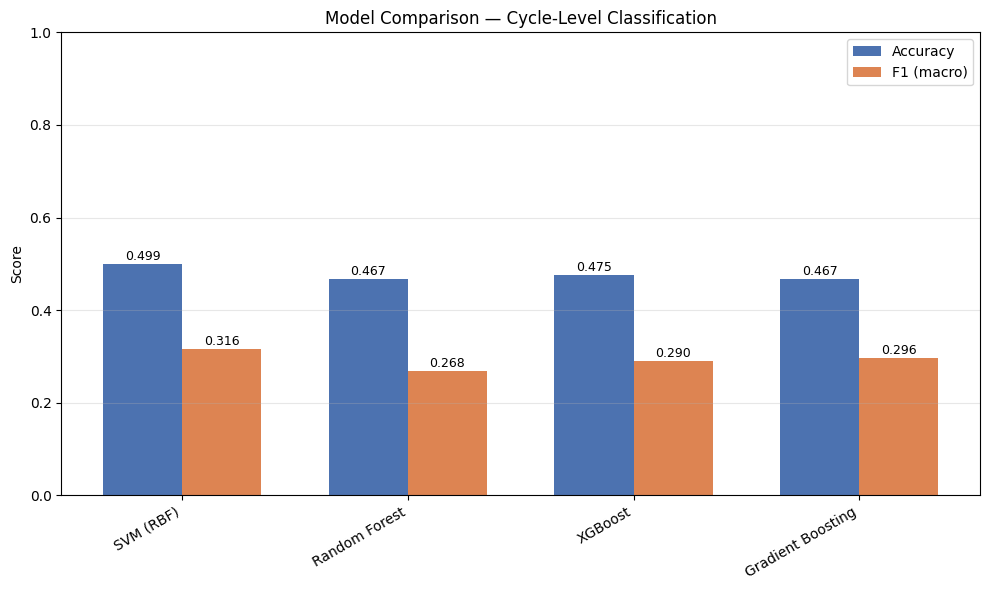

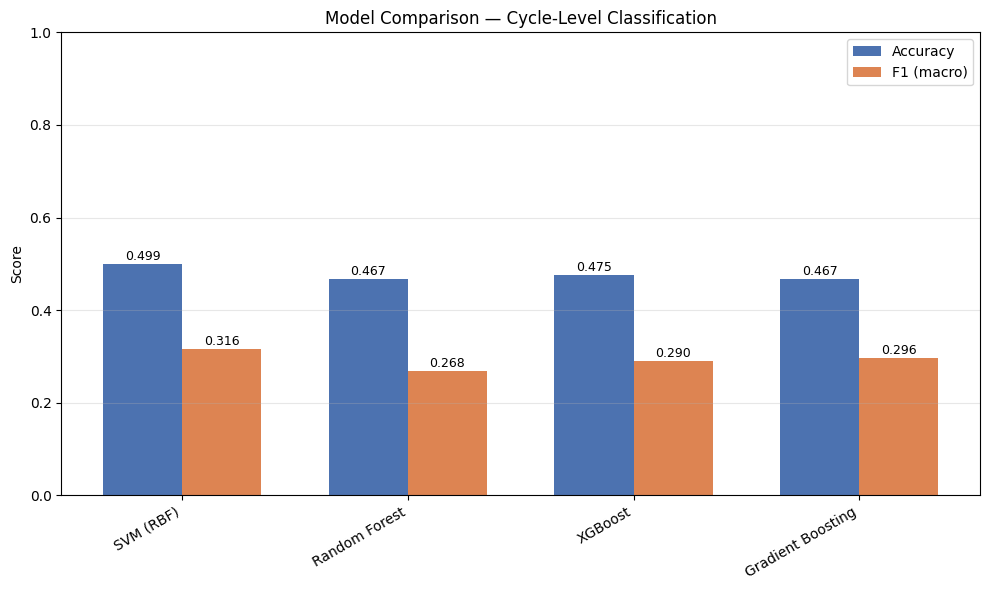

In [9]:
# Compare ML models
compare_models(ml_results, save_path=FIGURES_DIR / 'ml_model_comparison.png')